# Loading libraries

In [1]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from shapely.geometry import LineString
from itertools import combinations
from tqdm import tqdm
from scipy.optimize import minimize
from helper_functions_angle import resize_polygon, resize_polygon_MANTA, place_points, update_boundary, plot_coil
plt.rcParams['figure.figsize']=(6,6)
#plt.rcParams['font.weight']='bold'
#plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [2]:
tokamaker_python_path = '/home/jerem/tokamaker/OpenFUSIONToolkit/libs/install_release'
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk, eval_green
from OpenFUSIONToolkit.util import mu0

# 1. Equilibrium construction with TokaMaker (fixed boundary)

## Create mesh
First we define a target size to set the resolution in our grid. This variable will be used later and represent the target edge size within our mesh, where units are in meters. In this case we are using a fairly coarse resolution of 1.5 cm (10 radial points). Note that when setting up a new machine these values will need to scale with the overall size of the device/domain. It is generally a good idea perform a convergence study, by increasing resolution (decreasing target size) by at least a factor of two in all regions, when working with a new geometry to ensure the results are not sensitive to your choice of grid size.

### Define boundary

In [3]:
# Loading machine LCFS & shot from EQDSK file
#mesh_dx = 0.015 # for DIIID
mesh_dx = 0.03 # For MANTA

# Machine shot
#eqdsk = read_eqdsk('g192185.02440') # DIII-D
eqdsk = read_eqdsk('MANTA_posCS_final') # MANTA

# Plasma boundary 
LCFS_contour = eqdsk['rzout'].copy()

### Define regions, attributes & geometry for region boundaries
We now create the mesh object and define the various logical mesh regions. In this case we only have one region, which is named `plasma` and is of type `plasma`. 

In [4]:
# Create a G-S domain
gs_mesh = gs_Domain()

# Define region information for mesh
gs_mesh.define_region('plasma',mesh_dx,'plasma')

# Define mesh geometry 
gs_mesh.add_polygon(LCFS_contour,'plasma')

### Generate mesh & plotting resulting regions and grid
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

In [5]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()

Assembling regions:
  # of unique points    = 292
  # of unique segments  = 3
Generating mesh:
  # of points  = 9258
  # of cells   = 18222
  # of regions = 1


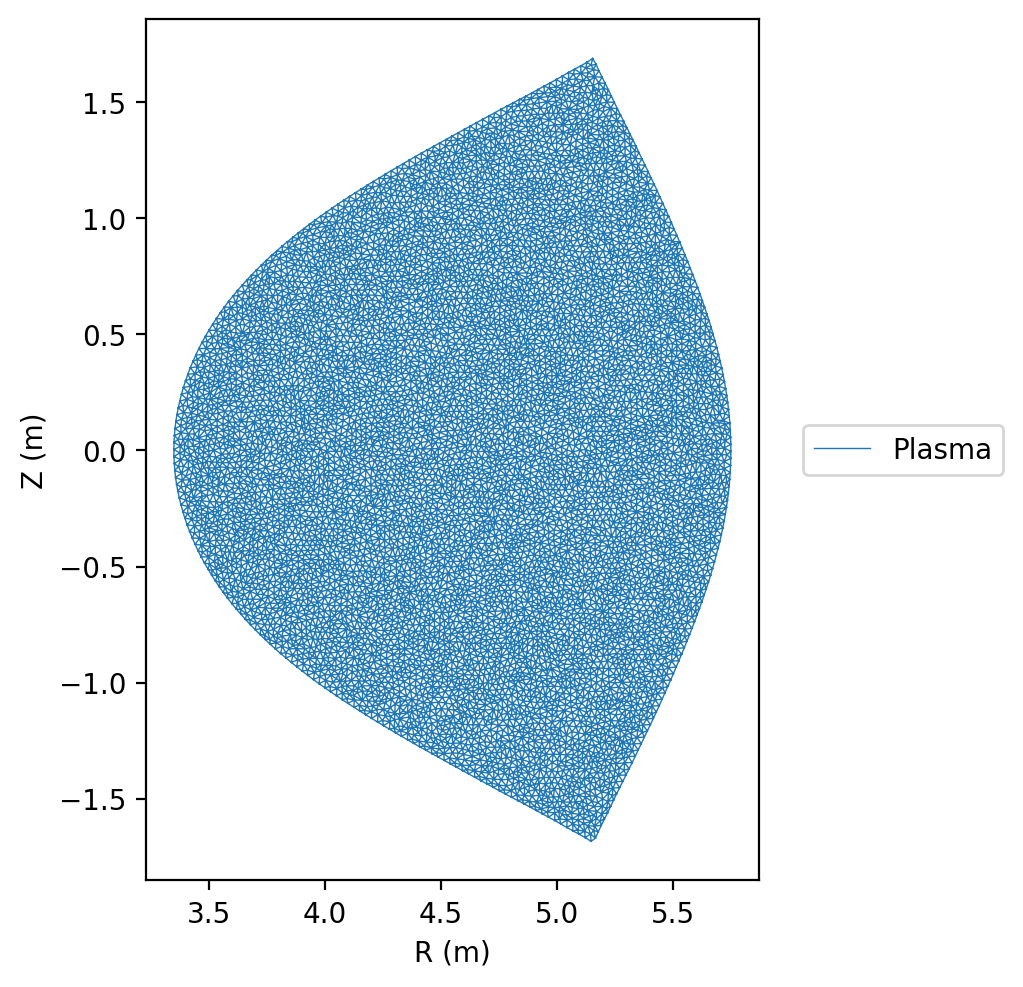

In [6]:
# Machine region and grid
fig, ax = plt.subplots(1,1,figsize=(5,8),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax)

## Compute equilibria

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script.

In [7]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          6165a5a
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /tmp/oft_11729/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated above using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh" and set the code to operate in fixed boundary mode by setting the `free_boundary` setting to False. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0.

In [8]:
mygs.setup_mesh(mesh_pts,mesh_lc)
mygs.settings.free_boundary = False

F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2,F0=F0)


**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  5.294E+00
    # of points  =    9258
    # of edges   =   27479
    # of cells   =   18222
    # of boundary points =     292
    # of boundary edges  =     292
    # of boundary cells  =     292
  Resolution statistics:
    hmin =  1.861E-02
    hrms =  2.729E-02
    hmax =  4.636E-02
  Surface grounded at vertex     206


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



### Define global quantities and targets
For the Grad-Shafranov solve we define targets for the plasma current and the pressure.

In [9]:
Ip_target = eqdsk['ip']
pres_target = eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=pres_target)

### Initialize the flux function & compute a fixed-boundary equilibrium
Before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi". By default this calculation uses a uniform current (equal to Ip_target) over the full plasma domain. Then we can compute an equilibrium in this geometry.

In [10]:
# flux function initialization
err_flag = mygs.init_psi()

# Computing the equilibrium
err_flag = mygs.solve()

Starting non-linear GS solver
     1  1.5609E+00  3.6446E-01  8.4019E-03  4.7605E+00  2.3744E-06  0.0000E+00
     2  5.5658E+00  2.8910E-01  2.3569E-03  4.7551E+00 -9.1980E-08  0.0000E+00
     3  6.4356E+00  2.7334E-01  8.3618E-04  4.7498E+00 -1.3459E-05  0.0000E+00
     4  6.6622E+00  2.6930E-01  3.3052E-04  4.7470E+00 -2.0418E-05  0.0000E+00
     5  6.7248E+00  2.6819E-01  1.3342E-04  4.7457E+00 -2.3593E-05  0.0000E+00
     6  6.7426E+00  2.6788E-01  5.3344E-05  4.7452E+00 -2.4964E-05  0.0000E+00
     7  6.7477E+00  2.6779E-01  2.1009E-05  4.7449E+00 -2.5526E-05  0.0000E+00
     8  6.7492E+00  2.6776E-01  8.1627E-06  4.7448E+00 -2.5748E-05  0.0000E+00
     9  6.7497E+00  2.6775E-01  3.1374E-06  4.7448E+00 -2.5834E-05  0.0000E+00
    10  6.7498E+00  2.6775E-01  1.1959E-06  4.7448E+00 -2.5866E-05  0.0000E+00
    11  6.7499E+00  2.6775E-01  4.5299E-07  4.7448E+00 -2.5878E-05  0.0000E+00
 Timing:  0.82399230499959231     
   Source:    0.56663864599795488     
   Solve:     0.20557942200

### Print information and plot equilibrium
After computing the equilibrium, basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats" can be used.

Flux surfaces can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi" method. Additional plotting methods are also available to display other information for more complex cases. See other examples and the documentation for more information.

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    1.0000E+07
  Current Centroid [m]    =    4.680 -0.000
  Magnetic Axis [m]       =    4.745 -0.000
  Elongation              =    1.343 (U:  1.343, L:  1.343)
  Triangularity           =   -0.459 (U: -0.459, L: -0.459)
  Plasma Volume [m^3]     =   154.584
  q_0, q_95               =    1.172  2.298
  Peak Pressure [Pa]      =    1.6366E+06
  Stored Energy [J]       =    1.3066E+08
  <Beta_pol> [%]          =   65.2937
  <Beta_tor> [%]          =    1.1549
  <Beta_n>   [%]          =    1.5228
  Diamagnetic flux [Wb]   =    1.9911E-01
  Toroidal flux [Wb]      =    5.8596E+01
  l_i                     =    0.7918


/tmp/ipykernel_11729/3150192173.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


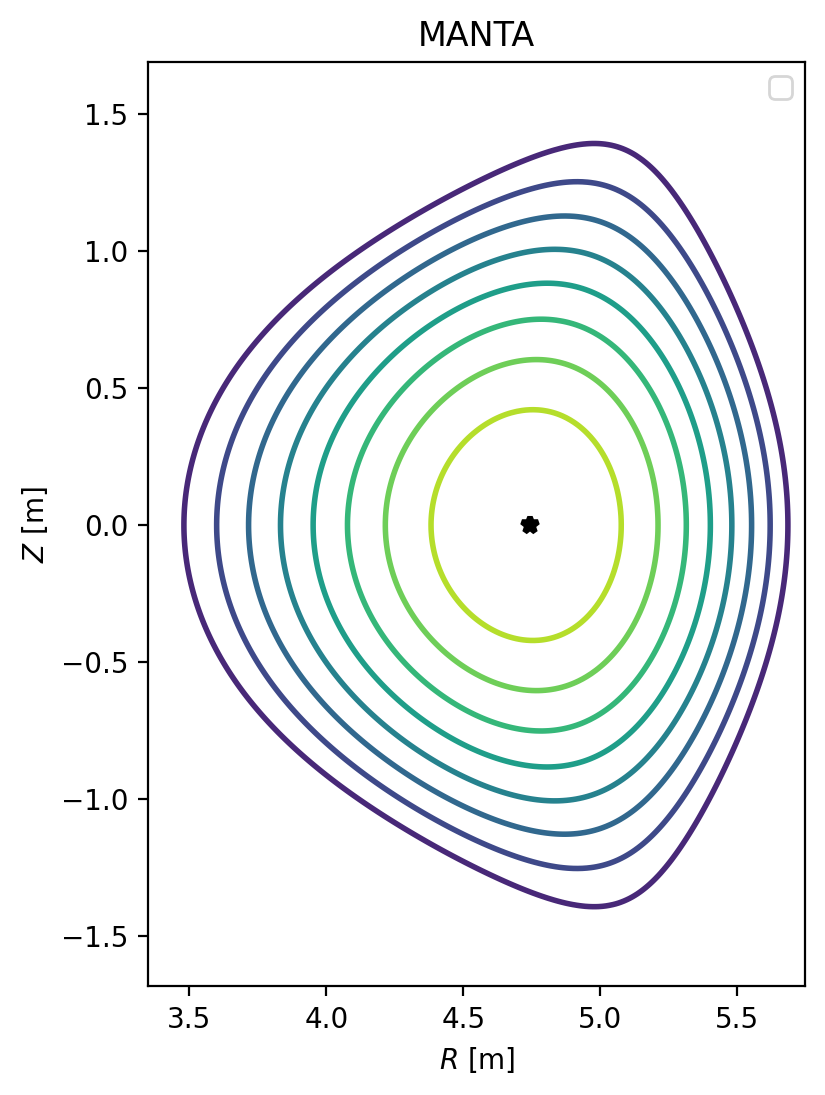

In [11]:
mygs.print_info()

# Plot flux surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_psi(fig,ax, plasma_nlevels=10)
plt.xlabel('$R$ [m]')
plt.ylabel('$Z$ [m]')
plt.title('DIII-D')
plt.title('MANTA')
plt.legend()

In [12]:
# will be one of the targets for the free-boundary case
fixed_mag_axis = mygs.o_point.copy()

## Boundary flux

- $r\_bnd$ represents the (R, Z) coord. along the fixed boundary where vacuum flux is evaluated (shape (n, 2))
- $psi\_bnd$ represents the required vacuum flux for balancing the fixed boundary equilibrium, at each of those boundary positions

Computing fixed boundary vacuum flux
 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.5658617000000002E-002
 Starting LU solver: umfpack T


Text(0.5, 1.0, 'DIII-D')

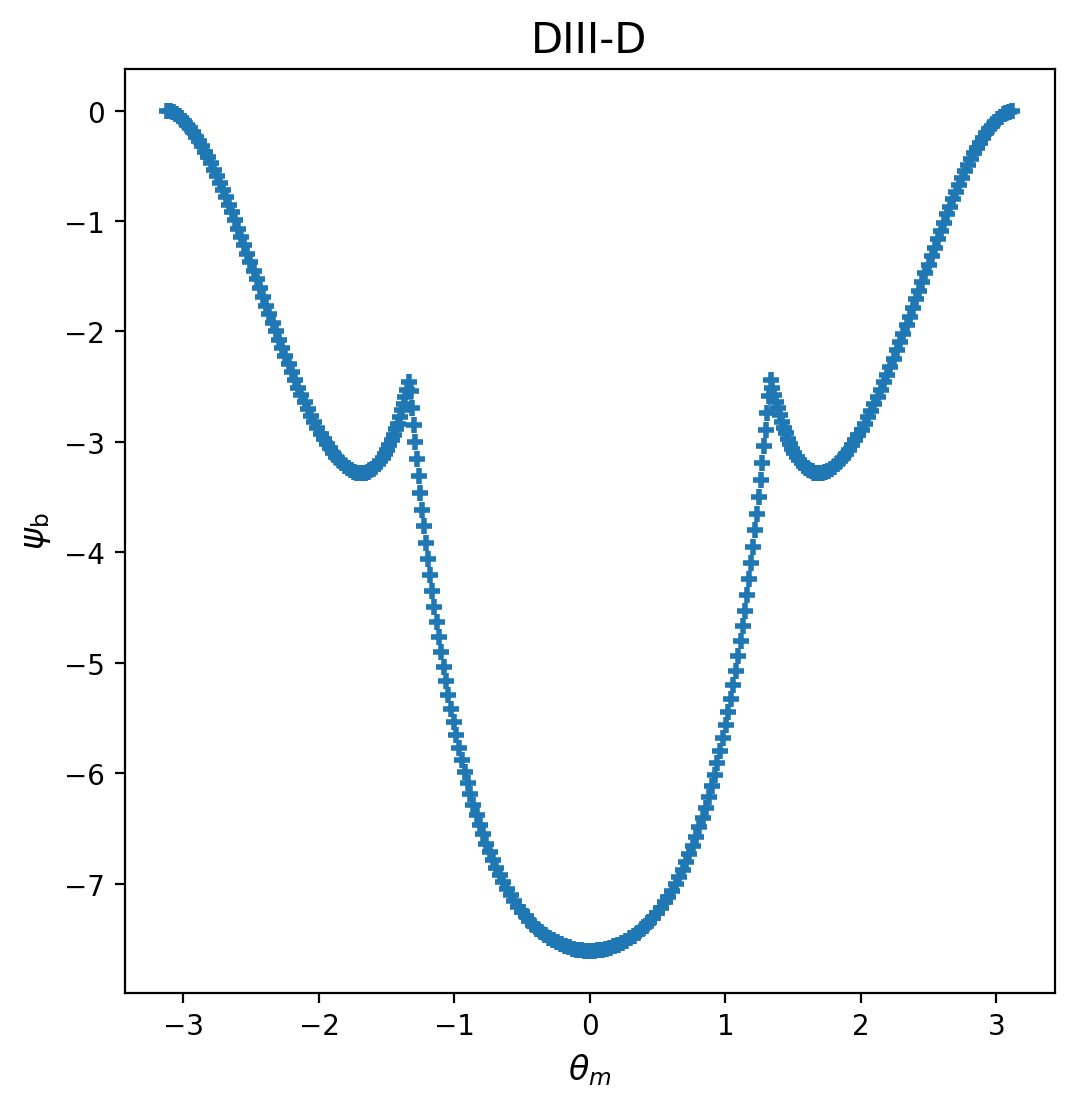

In [13]:
r_bnd, psi_bnd = mygs.get_vfixed()

# Plot required relative flux on boundary
fig, ax = plt.subplots()
theta = np.arctan2(r_bnd[:,1],r_bnd[:,0]-mygs.o_point[0])
_=ax.plot(theta[1:],psi_bnd[1:]-psi_bnd[0],'+')
plt.xlabel(r"$\theta_{m}$", fontsize=12)
plt.ylabel(r'$\psi_{\text{b}}$', fontsize=12)
plt.title('DIII-D', fontsize=15)

# 2. Optimization

## Geometry of the machine: Run either DIII-D or MANTA

### DIII-D

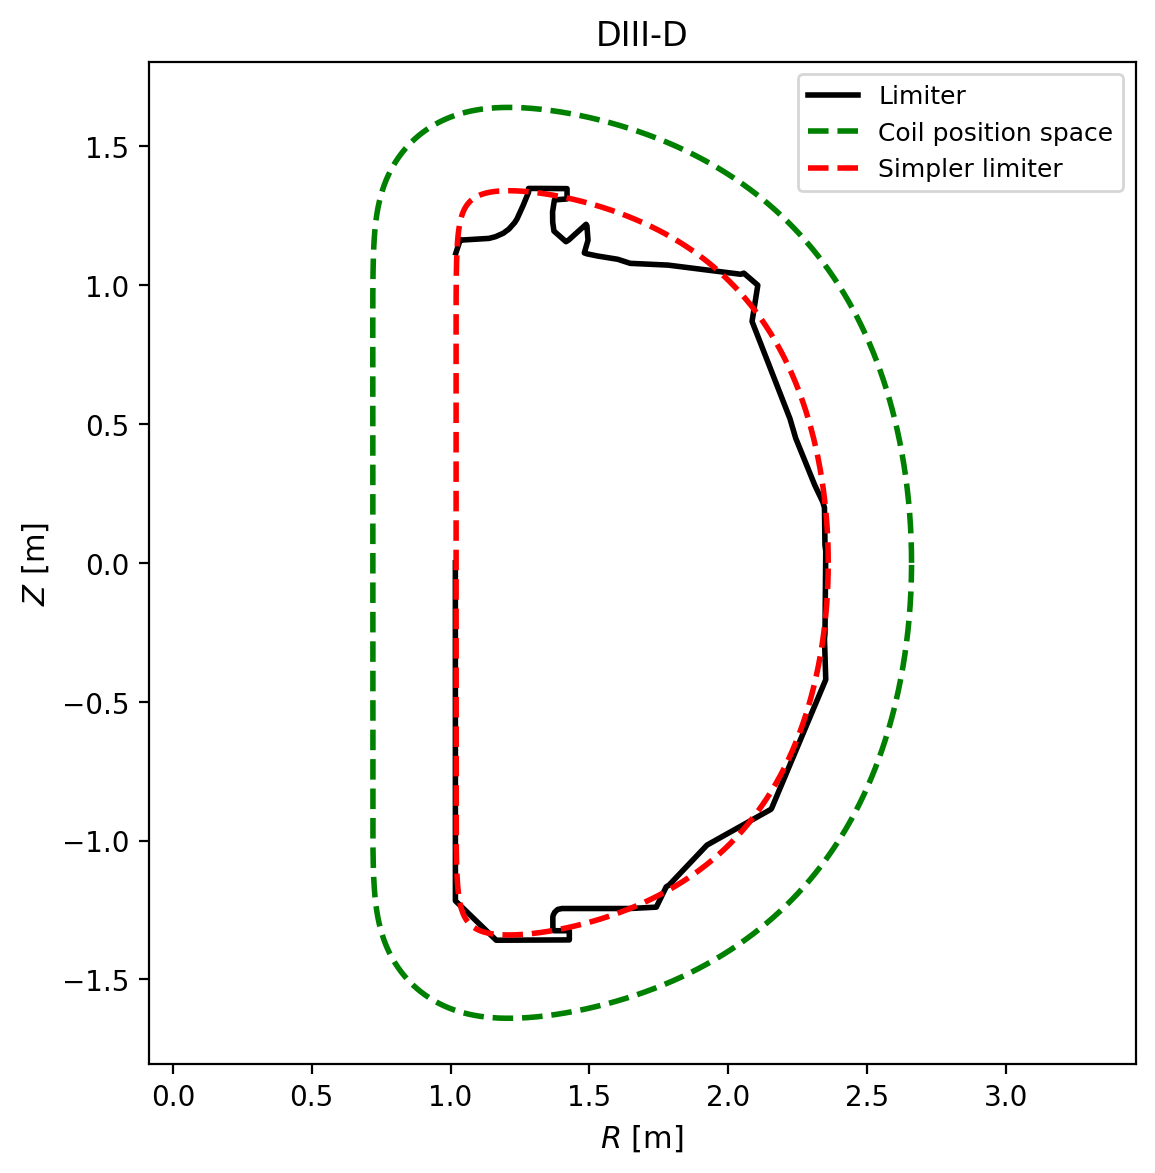

In [14]:
# Geometry
with open('DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Get the machine limiter
lim0 = np.array(DIIID_geom['limiter'])

# generates a modified limiter (return a list of (R,Z) coord of plasma bound.)
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) # DIII-D
                                                                                       
# coil_centers_cand contains 'npts' candidate positions (dx: dist between limiter and coils)
coil_center_cand = resize_polygon(lim, dx=0.3)

plt.figure(figsize=(6, 6))
plt.plot(lim0[:,0], lim0[:,1], 'k', label='Limiter')
plt.plot(coil_center_cand[:,0], coil_center_cand[:,1], 'g--', label='Coil position space')
plt.plot(lim[:,0], lim[:,1], 'r--', label='Simpler limiter')

# Labels, legend, and layout
plt.title('DIII-D')
plt.xlabel('$R$ [m]', fontsize=11)
plt.ylabel('$Z$ [m]', fontsize=11)
plt.axis('equal')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### MANTA

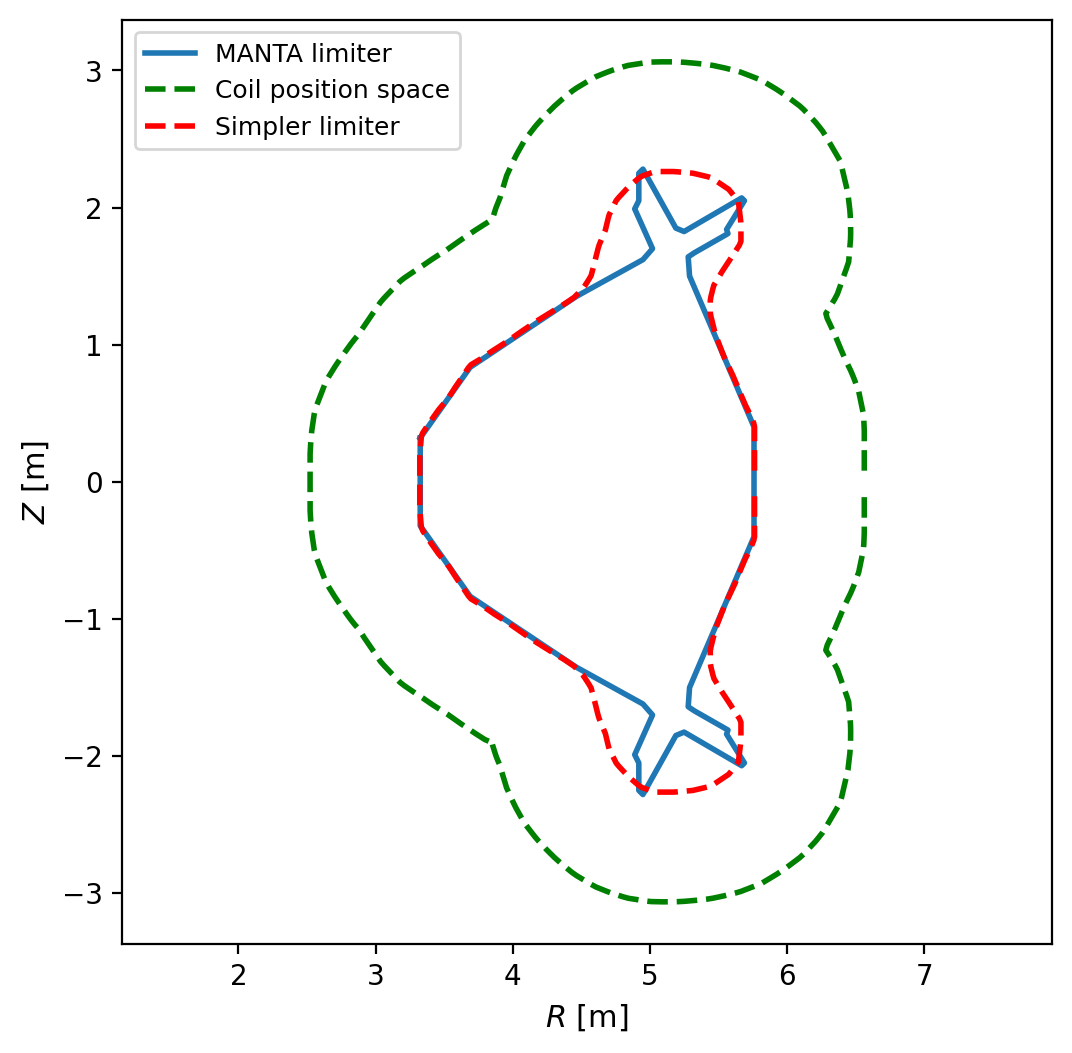

In [14]:
def make_limiter(rtop, ztop, npts=400, plot=True):
    """
    Compute the full limiter (top and bottom side) from the given top side arc,
    making the latter evenly spaced. The limiter must be up-down symmetric. rtop
    & ztop can be provided for example using plotdigitizer.com  

    Parameters:
        - rtop: R-coord. of points defining the limiter top-side (list)
        - ztop: Z-coord. of points defining the limiter top-side (list)
        - npts: number of points defining the limiter
        - plot: Plot the full limiter (Boolean)

    returns:
        - limiter: (R,Z) coord of the limiter (2D array) 
    """
    # Constructing the bottom side
    rbot = rtop[::-1] 
    zbot = ztop[::-1]
    zbot = [-z_pt for z_pt in zbot]

    # Full (R,Z) coord
    r = rtop + rbot
    z = ztop + zbot

    # Converting into 2D array
    lim_coord = np.array(list(zip(r, z)))

    # Computing cumulative arc length
    deltas = np.diff(lim_coord, axis=0)
    dists = np.hypot(deltas[:, 0], deltas[:, 1])
    arc_length = np.concatenate([[0], np.cumsum(dists)])
    tot_length = arc_length[-1]

    # Interpolation functions for R and Z
    R_interp = interpolate.interp1d(arc_length, lim_coord[:, 0], kind='linear')
    Z_interp = interpolate.interp1d(arc_length, lim_coord[:, 1], kind='linear')

    # Creating evenly spaced arc length
    new_arc_length = np.linspace(0, tot_length, npts)

    # Interpolated new points
    new_R = R_interp(new_arc_length)
    new_Z = Z_interp(new_arc_length)

    # Plot the limiter geometry
    if plot:
        plt.plot(new_R, new_Z, label='MANTA limiter')
        plt.xlabel('$R$ [m]', fontsize=11)
        plt.ylabel('$Z$ [m]', fontsize=11)
        plt.axis('equal')
        plt.legend()

    return np.column_stack([new_R, new_Z])


def resample_curve(x, y, n_points=100, kind='linear'):
    """
    Resample a 2D curve defined by x and y to have evenly spaced points along the arc length.

    Parameters:
        - x: x-coordinates of the original curve
        - y: y-coordinates of the original curve
        - n_points: Number of evenly spaced points
        - kind: Interpolation kind ('linear', 'quadratic', 'cubic', etc.)

    Returns:
        - x_resampled: Resampled x-coordinates
        - y_resampled: Resampled y-coordinates
    """
    # Compute cumulative arc length
    x = np.asarray(x)
    y = np.asarray(y)
    dx = np.diff(x)
    dy = np.diff(y)
    arc_lengths = np.sqrt(dx**2 + dy**2)
    cumulative_arc = np.concatenate(([0], np.cumsum(arc_lengths)))

    # Interpolating functions for x(s) and y(s)
    interp_x = interp1d(cumulative_arc, x, kind=kind)
    interp_y = interp1d(cumulative_arc, y, kind=kind)

    # New arc length values (evenly spaced)
    new_arc = np.linspace(0, cumulative_arc[-1], n_points)

    # Resampled coordinates
    x_resampled = interp_x(new_arc)
    y_resampled = interp_y(new_arc)

    return x_resampled, y_resampled

def find_self_intersection_points(coords):
    """
    Detect the first intersection point in a sequence of 2D coords.
    """
    from shapely.geometry import LineString

    line = LineString(coords)
    if line.is_simple:
        return None

    # Check all non-consecutive segment pairs
    for (i1, i2) in combinations(range(len(coords)-1), 2):
        if abs(i1 - i2) <= 1:
            continue  # skip consecutive segments

        seg1 = LineString([coords[i1], coords[i1+1]])
        seg2 = LineString([coords[i2], coords[i2+1]])
        if seg1.intersects(seg2):
            pt = seg1.intersection(seg2)
            if pt.geom_type == 'Point':
                return i1+1, i2  # return indices between which the loop occurs

    return None

def remove_all_loops(coords, max_iter=10):
    """
    Remove all loops (self-intersections) from a sequence of 2D coordinates.
    Stops when no intersection is found or max_iter is reached.

    Parameters:
        - coords: Curve coordinates (with intersection)
        - max_iter: Max number of iteration

    Returns:
        - coord_clean: Curve coordinates without intersection

    """
    coords_clean = coords.copy()
    
    for _ in range(max_iter):
        result = find_self_intersection_points(coords_clean)
        if result is None:
            break  # No more loops
        i, j = result
        if i < j:
            coords_clean = np.concatenate([coords_clean[:i], coords_clean[j:]], axis=0)
        else:
            coords_clean = np.concatenate([coords_clean[:j], coords_clean[i:]], axis=0)
    return coords_clean

# Simpler limiter from plotDigitizer
x = [5.763975155279503, 5.763975155279503, 5.763975155279503, 5.763975155279503, 5.763975155279503, 5.739130434782608, 5.695652173913043, 5.658385093167702, 5.614906832298137, 5.540372670807454, 5.478260869565217, 5.440993788819876, 5.440993788819876, 5.46583850931677, 5.521739130434782, 5.596273291925465, 5.6645962732919255, 5.6645962732919255, 5.645962732919255, 5.577639751552795, 5.447204968944099, 5.316770186335404, 5.180124223602484, 5.037267080745341, 4.93167701863354, 4.84472049689441, 4.75776397515528, 4.7018633540372665, 4.6770186335403725, 4.627329192546584, 4.596273291925465, 4.571428571428571, 4.515527950310559, 4.447204968944099, 4.3726708074534155, 4.279503105590062, 4.180124223602484, 4.086956521739131, 3.962732919254658, 3.8633540372670807, 3.763975155279503, 3.6894409937888195, 3.639751552795031, 3.5838509316770186, 3.527950310559006, 3.4596273291925463, 3.3975155279503104, 3.3354037267080745, 3.329192546583851, 3.3229813664596275, 3.3229813664596275, 3.3229813664596275]
y = [0.08125000000000027, 0.17500000000000027, 0.27500000000000036, 0.3500000000000001, 0.4125000000000001, 0.4750000000000001, 0.5625, 0.6500000000000004, 0.7562500000000001, 0.9125000000000001, 1.0750000000000002, 1.225, 1.3312500000000003, 1.4312500000000004, 1.5250000000000004, 1.6375000000000002, 1.7437500000000004, 1.8875000000000002, 2.04375, 2.1312500000000005, 2.21875, 2.25, 2.2625, 2.2625, 2.2250000000000005, 2.1500000000000004, 2.0562500000000004, 1.9437500000000005, 1.8375000000000004, 1.71875, 1.59375, 1.5, 1.4125, 1.34375, 1.2937500000000002, 1.2375000000000003, 1.1750000000000003, 1.1125000000000003, 1.0250000000000004, 0.9625000000000004, 0.8937500000000003, 0.8500000000000001, 0.7750000000000004, 0.6937500000000001, 0.6062500000000002, 0.5250000000000004, 0.4375, 0.34375, 0.26875000000000027, 0.20000000000000018, 0.15000000000000036, 0.08750000000000036]


# MANTA Geometry
with open('MANTA_geom.json','r') as fid:
    MANTA_geom = json.load(fid)

# Get MANTA limiter
lim0 = np.array(MANTA_geom['limiter'])

# Create simpler limiter coil position space (cps)
lim = make_limiter(x, y, 400, plot=False)

# Make the simpler limiter evenly spaced
lim[:,0], lim[:,1] = resample_curve(lim[:,0], lim[:,1], 400)

# Create coil position space
coil_center_cand_tmp = resize_polygon_MANTA(lim, 0.8)
coil_center_cand_tmp = remove_all_loops(coil_center_cand_tmp)

# Make coil position space evenly spaced
rspace, zspace = resample_curve(coil_center_cand_tmp[:,0], coil_center_cand_tmp[:,1], 400)
coil_center_cand = np.column_stack((rspace, zspace))

# Plot limiter and coil position space
plt.figure(figsize=(6, 6))
plt.plot(lim0[:,0], lim0[:,1], label='MANTA limiter')
plt.plot(coil_center_cand[:, 0], coil_center_cand[:, 1], 'g--', label='Coil position space', markersize=50)
plt.plot(lim[:,0], lim[:,1], 'r--', label='Simpler limiter')
plt.xlabel('$R$ [m]', fontsize=11)
plt.ylabel('$Z$ [m]', fontsize=11)
plt.axis('equal')
plt.legend(fontsize=9)

## Coils positioning

In [15]:
def make_new_coils(nCoils, pol_angles, dx=0.08, dy=0.08, ifplot=True, distribution2=None):
    """
    Generates and places poloidal field (PF) coils given their poloidal angles pol_angles. 
    It creates a set of coil pairs (one above and one below the midplane) whose
    size can be changed thanks to dx & dy. Optionally plots two coil configurations.

    Parameters:
        - nCoils: Number of coils (in the top-side)
        - pol_angles: List of poloidal angles in top-side (degrees)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - ifplot: Boolean, whether to plot the given coil distribution
        - distribution2: (Optional) second list of poloidal angles

    Returns:
        - scan_geom (dictionary): Dict. containing the data of the coil distr.
    """
    
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2,:], pol_angles)
    
    # Creating coil pairs for 1st distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    if ifplot:
        # Make the figure
        plt.figure(figsize=(4, 6))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        plt.plot(lim[:, 0], lim[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
            if 'ECOIL' not in coil:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                #plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        # If provided, plot the (2nd) distrib
        if distribution2 is not None:
            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2, :], distribution2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for the 2nd distrib
                scan_geom_2["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils in a different color (e.g., red)
            for coil in scan_geom_2["coils"]:
                if 'ECOIL' not in coil:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')

    return scan_geom

## Core functions

In [16]:
def compute_coil_centers(scan_geom):
    """
    Compute the center of each coils

    Parameter: 
        - scan_geom: dict with coils informations
        
    return:   
        - coil_centers: coils centers of both top & bottom side (2D array, (R,Z) positions)
    """
    coil_centers = []

    # Mean of coil edges for each coil
    for i, coil in enumerate(scan_geom["coils"]):
        pts = np.array(scan_geom["coils"][coil]["pts"])
        center = np.mean(pts, axis=0) 

        # Store the center as a pair (for a single coil)
        coil_centers.append(np.asarray([center]))  # Each element is a 2D array with one center

    return coil_centers

In [17]:
def make_3x3_thick(center, R):
    """
    Generate the centers of 9 tangent cables forming a 3x3 coil.

    Parameters:
    - center: (R, Z) coord. of the central filament
    - R: Coil filament radius 

    Returns:
    - List of (R, Z) coord. for each cable center
    """
    R0, Z0 = center
    offsets = [-1, 0, 1]
    fil_centers = []

    # Grid scan
    for dx in offsets:
        for dy in offsets:
            fil_centers.append([R0 + 2 * R * dx, Z0 + 2 * R * dy])

    return fil_centers

In [18]:
def opt_coil_loc_curr3x3_default(init_angles, bounds=None, Rfil=0.01, reg_in=1e-7, BFGS=True, scan=False, plot_err=False, plot_info=True):
    """
    Performs an outer-loop optimization over the poloidal coil positions with regularization terms. 
    For each configuration, it solves an inner loop (Least-Squares problem) in order to get 
    the optimal coil currents that minimize the flux error on the boundary. Then, the final error 
    from this inner problem is used as the cost function for optimizing coil locations. 

    Arguments:
        - init_angles: Initial list of poloidal angles (degrees) in top-side
        - bounds: specify the bounds in which each poloidal angle can vary (list) 
        - Rfil: Coil filament radius
        - reg_in: Regularization term in inner loop
        - BFGS: if True, perform outer loop. If False, only performs inner loop
        - scan: if True, return more revelant informations about the opt. process
        - plot_err: if True, plot the flux error

    Returns:
        - result.x: Optimized coil positions as an array of poloidal angles in top-side (degrees)
        - result.fun: Final cost of the outer loop
        - final_currs: Optimized currents (top & bottom side)
    """
    # Number of coils in the upper part (with symmetry, the total number of coils is 2 * num_coils)
    num_coils = len(init_angles)

    # Storing final results
    final_currs = None 
    final_con = None    
    inner_cost = None

    def objective(pol_distr):
        """
        Objective function determining the lowest electric currents while reproducing a target 
        plasma boundary shape, solving a regularized Least-Squares problem.
        
        Arguments:
            - pol_distr: List of poloidal angles in top-side (degrees)
        
        Returns:
            -  final_cost[0]: Cost function value based on optimal currents for the given positions
        """
        nonlocal final_currs, final_con, inner_cost

        # Loading new coil configuration (name, positions, etc)
        scan_geom_DIIID = make_new_coils(num_coils, pol_distr, ifplot=False)

        # Compute coil centers
        new_coil_center = compute_coil_centers(scan_geom_DIIID)

        # Add 3x3 thickness to each coil
        new_coil_center_3x3 = []

        for i, center in enumerate(new_coil_center):
            thick_centers = make_3x3_thick(center[0], Rfil)
            new_coil_center_3x3.append(thick_centers)

        ### Inner loop: Least Squares ###############     
        con = np.zeros((psi_bnd.shape[0]+len(new_coil_center_3x3)-1, len(new_coil_center_3x3)))
        
        for i, filament_set in enumerate(new_coil_center_3x3):
            flux_tmp = np.zeros((psi_bnd.shape[0],))
            for fil in filament_set:
                flux_tmp += eval_green(r_bnd, fil)
            con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
            con[psi_bnd.shape[0]-1+i,i] = reg_in # Regularization term

        # Performs least-squares fit
        err = np.zeros((psi_bnd.shape[0]+len(new_coil_center_3x3)-1,))
        err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
        currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
        #################################

        # Store the final currents, con matrix & inner cost
        final_currs = currs
        final_con = con    
        inner_cost = final_cost[0].copy()
        
        if BFGS:
            return inner_cost 
        else:
            return inner_cost, final_currs
    
    # outer loop: PF coil position optimization
    if BFGS:
        result = minimize(objective, init_angles, method='L-BFGS-B', bounds=bounds, tol = 1e-6, options={'disp': True})

        # Plot flux error
        if plot_err == True:
            # Ensure final_con is not None before plotting
            if final_con is not None and final_currs is not None:
                fig, ax = plt.subplots()
                ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
                ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
                # Add reg_in to legend
                ax.plot([], [], ' ', label=fr"$\lambda_{{\mathrm{{in}}}} = {reg_in:.1e}$")
                ax.set_xlabel("$\Theta$", fontsize=12)
                ax.set_ylabel("boundary flux")
                ax.legend()
                plt.show()
        
        if plot_info is True:
            # Print outer loop informations
            print("outer cost: ", result.fun)
            print("inner cost: ", inner_cost)
            print("number of iterations for the outer loop: ", result.nit)
            print("success: ", result.success)
            print("status: ", result.status)
            print("message: ", result.message)
        if scan is True:
            return result.x, result.fun, final_currs, inner_cost
        else:
            # Optimized distributions
            return result.x, final_currs
    else:
        return objective(init_angles)

<>:95: SyntaxWarning: invalid escape sequence '\T'
<>:95: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_11729/1945775193.py:95: SyntaxWarning: invalid escape sequence '\T'
  ax.set_xlabel("$\Theta$", fontsize=12)


# Examples

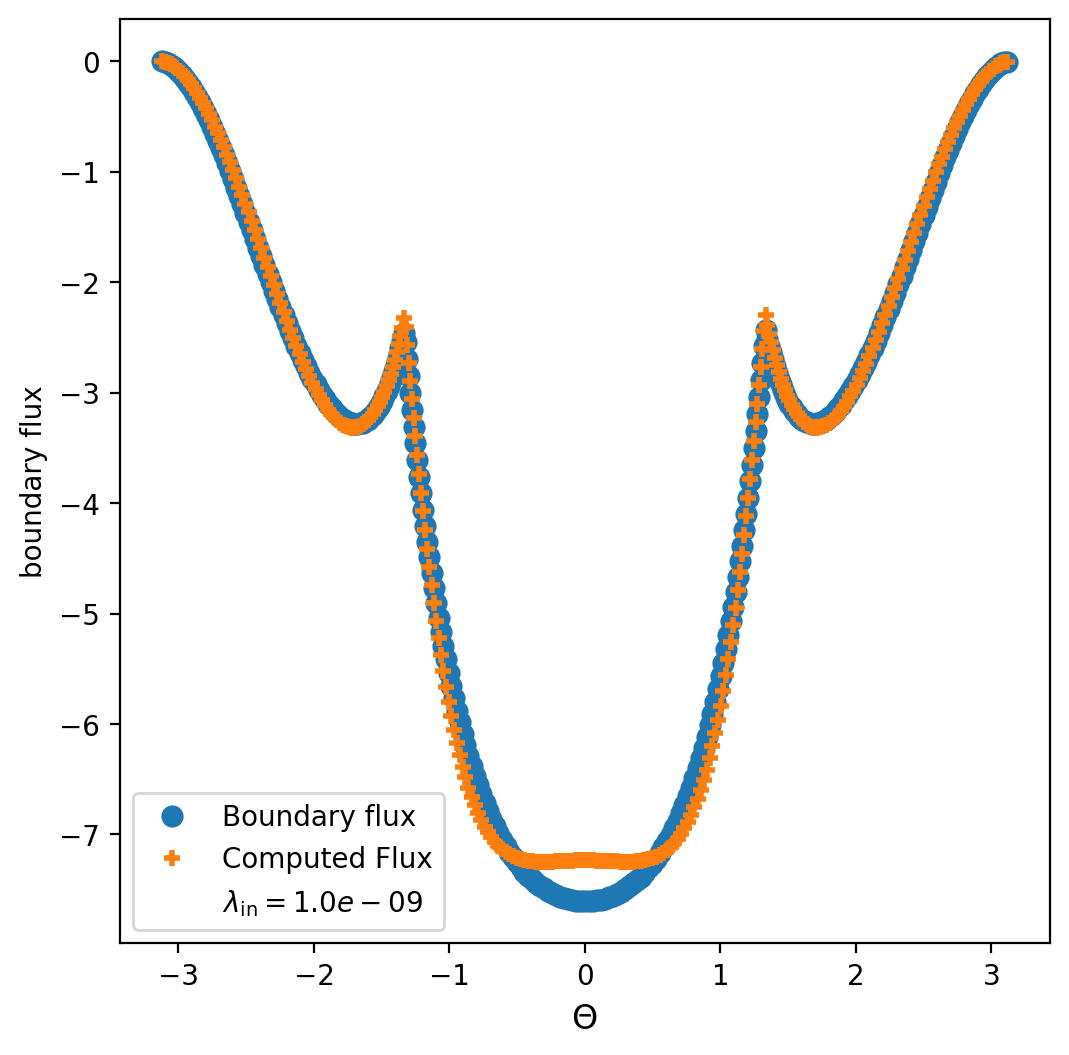

outer cost:  5.924883607372265
inner cost:  5.924883607530247
number of iterations for the outer loop:  20
success:  True
status:  0
message:  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Initial distribution : [40, 90, 140]
optimal distribution : [ 29.84924622  63.04897029 121.34381373]


In [19]:
# Parameters
init_distr = [40, 90, 140]
bounds = [(0, 180)] * len(init_distr)
reg = 1e-9

# Optimization
opt_distr, outer_cost, currents, inner_cost = opt_coil_loc_curr3x3_default(init_distr, bounds, reg_in=reg, plot_err=True, scan=True)

# Plot infos
print("Initial distribution :", init_distr)
print("optimal distribution :", opt_distr)

## Coil visualization

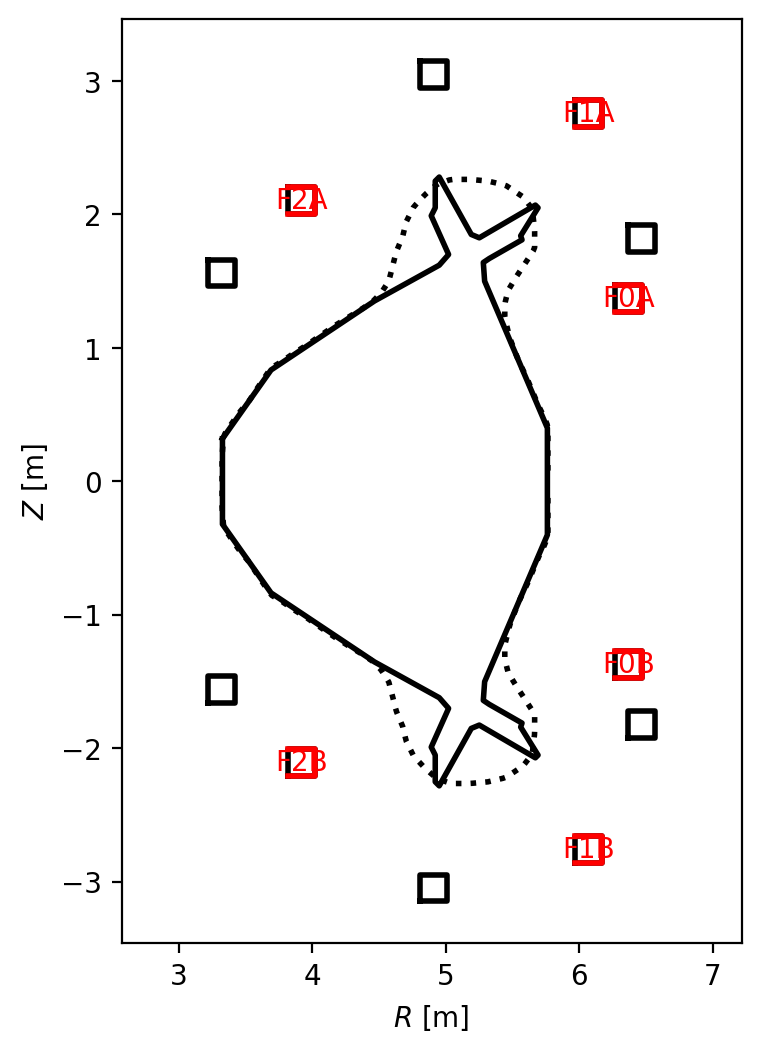

In [20]:
# Coil visualization
# initial -> black
# optimal -> red
_ = make_new_coils(nCoils=len(opt_distr), pol_angles=init_distr, distribution2=opt_distr, dx=0.1, dy=0.1)

## Plotting currents

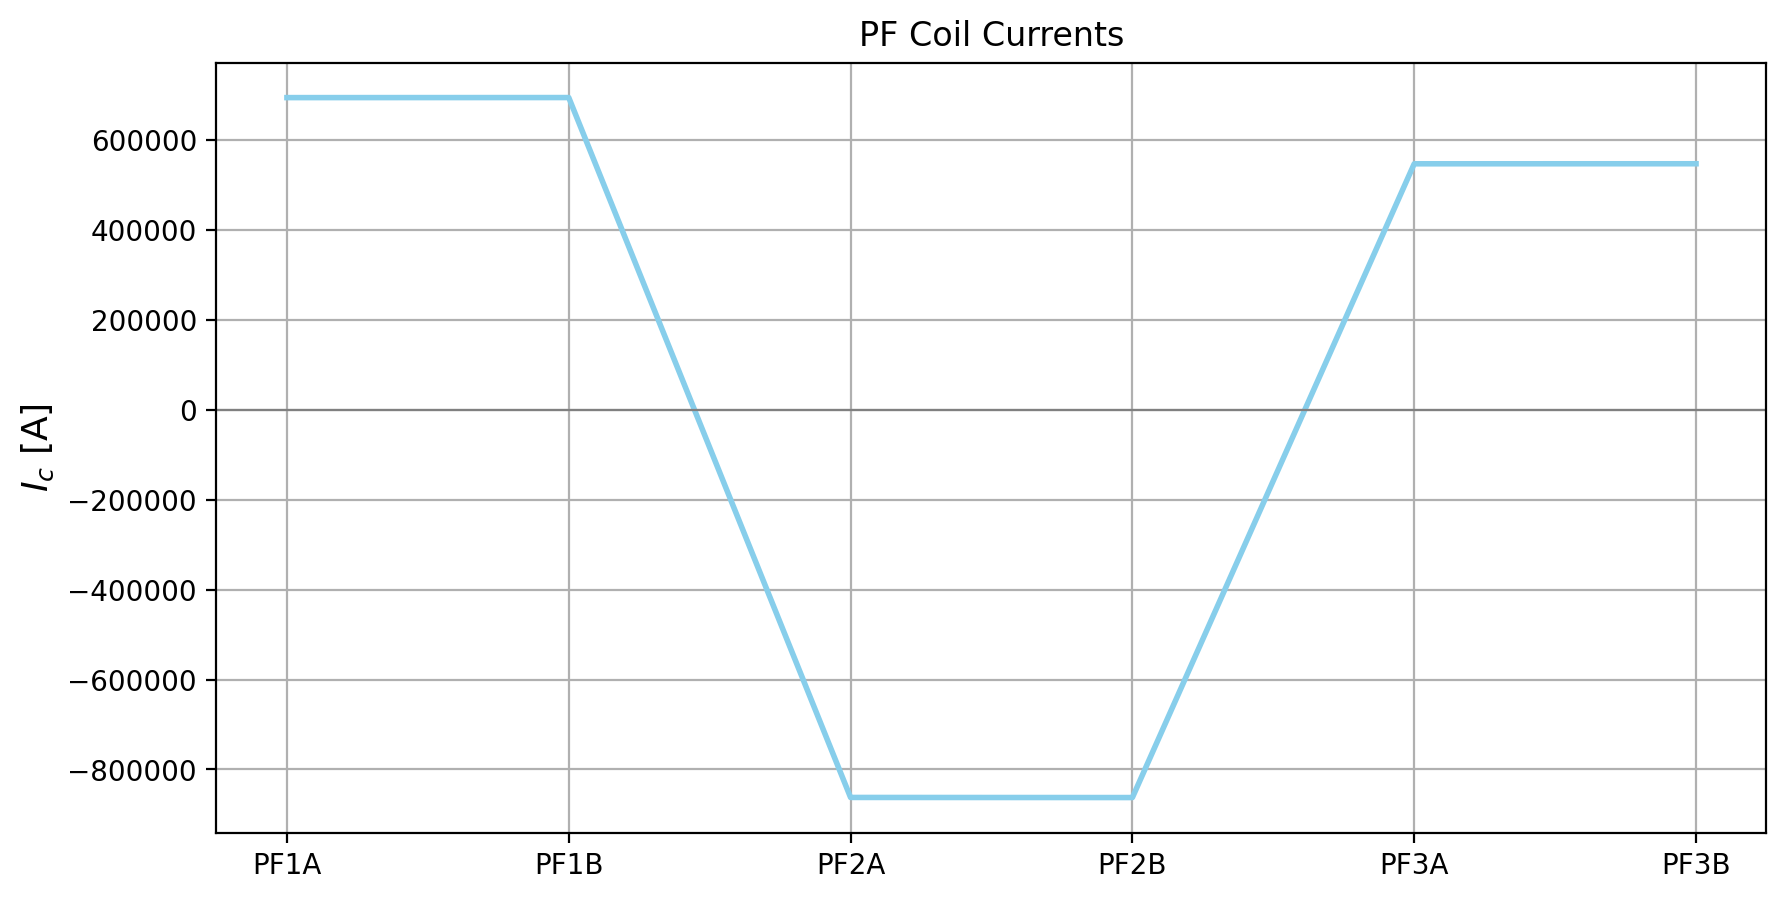

In [21]:
n_coils = len(currents) // 2
labels = [f"PF{i+1}{letter}" for i in range(n_coils) for letter in ('A', 'B')]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(labels, currents, color='skyblue')
plt.axhline(0, color='gray', linewidth=0.8) 
plt.ylabel(r"$I_{c}$ [A]", fontsize=13)
plt.title("PF Coil Currents")
plt.grid('True')
